## <center>CSE 546: Reinforcement Learning</center>
### <center>Prof. Alina Vereshchaka | Spring 2026</center>

# Assignment 3 — Part II: Advantage Actor-Critic (A2C)


**Algorithm**: Synchronous Advantage Actor-Critic (A2C)  
**Environment**: CartPole-v1  
**Workers**: 2 parallel actor-learner threads


## Section 0: Setup and Imports


In [1]:
%matplotlib inline
import io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import threading
import queue
import matplotlib.pyplot as plt
import os, sys, time
from collections import deque
from IPython.display import display, Image, Video, Markdown

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'PyTorch {torch.__version__} | Gymnasium {gym.__version__}')
print('Plots/video are embedded in notebook outputs; .png/.mp4 also saved for submission.')


PyTorch 2.11.0 | Gymnasium 1.2.3
Plots/video are embedded in notebook outputs; .png/.mp4 also saved for submission.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────

ENV_NAME      = 'CartPole-v1'  # Gymnasium environment ID
N_WORKERS     = 2              # Number of parallel worker threads
N_STEPS       = 20             # Rollout length for n-step returns (20 works well for CartPole-v1)
MAX_EPISODES  = 3200           # More episodes so the shared policy reliably passes the ~475 solve line
GAMMA         = 0.99           # Discount factor for n-step returns
HIDDEN_DIM    = 256            # Wider trunk; reporting below follows Gym "solved": avg >= 475 over 100 consecutive finished episodes
LR            = 1e-3           # Adam step size (standard for small actor-critic on CartPole)
ENT_COEF      = 0.01           # Entropy bonus (too low early on can collapse the policy before the critic learns)
VF_COEF       = 0.5            # Value-function loss weight
MAX_GRAD_NORM = 50.0           # Gradient clipping (same spirit as the assignment defaults)

# Disk layout: all artifacts under a2c_cartpole_outputs/ (created here; absolute paths printed below).
from pathlib import Path

A2C_OUTPUT_ROOT = (Path.cwd() / 'a2c_cartpole_outputs').resolve()
A2C_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(A2C_OUTPUT_ROOT / 'checkpoints').mkdir(exist_ok=True)
(A2C_OUTPUT_ROOT / 'figures').mkdir(exist_ok=True)
(A2C_OUTPUT_ROOT / 'videos').mkdir(exist_ok=True)

WEIGHTS_PATH = A2C_OUTPUT_ROOT / 'checkpoints' / 'a2c_cartpole_weights.pth'
TRAINING_PLOT_PATH = A2C_OUTPUT_ROOT / 'figures' / 'a2c_cartpole_training.png'
EVAL_PLOT_PATH = A2C_OUTPUT_ROOT / 'figures' / 'a2c_cartpole_eval.png'
VIDEO_DIR = str(A2C_OUTPUT_ROOT / 'videos')

# Gymnasium CartPole-v1 official SOLVED rule (logs + plots use these numbers):
SOLVED_THRESHOLD = 475   # minimum *average* return in the window below
SOLVED_WINDOW    = 100   # number of consecutive *finished* episodes in that average

# Exact wording (CartPole-v1): headline + full window wording
GYM_SOLVED_HEADLINE = f'Gym "solved": average return ≥ {SOLVED_THRESHOLD}'
GYM_SOLVED_FULL = (
    f'{GYM_SOLVED_HEADLINE} — average taken over the last {SOLVED_WINDOW} consecutive finished episodes'
)

print('Hyperparameters loaded.')
print(f'  ENV={ENV_NAME}  N_WORKERS={N_WORKERS}  N_STEPS={N_STEPS}')
print(f'  MAX_EPISODES={MAX_EPISODES}  GAMMA={GAMMA}  LR={LR}')
print()
print('  >>>', GYM_SOLVED_FULL)
print()

print('  Artifact paths (files appear after train / save / plot / video cells):')
print(f'    root         {A2C_OUTPUT_ROOT}')
print(f'    weights      {WEIGHTS_PATH}')
print(f'    train plot   {TRAINING_PLOT_PATH}')
print(f'    eval plot    {EVAL_PLOT_PATH}')
print(f'    videos dir   {VIDEO_DIR}')
print()


Hyperparameters loaded.
  ENV=CartPole-v1  N_WORKERS=2  N_STEPS=20
  MAX_EPISODES=3200  GAMMA=0.99  LR=0.001

  >>> Gym "solved": average return ≥ 475 — average taken over the last 100 consecutive finished episodes

  Artifact paths (files appear after train / save / plot / video cells):
    root         /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs
    weights      /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/checkpoints/a2c_cartpole_weights.pth
    train plot   /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_training.png
    eval plot    /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_eval.png
    videos dir   /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226

---
## Part II — Discussion

### 1. Roles of the Actor and Critic

In Actor-Critic methods, the agent is decomposed into two cooperating components:

**Actor** — the policy `π(a|s; θ)`. It maps states to a probability distribution over actions and is responsible for deciding *what to do*. During training, the actor is updated to increase the probability of actions that lead to better-than-expected outcomes (high advantage) and decrease the probability of worse-than-expected actions. The actor is what gets deployed at evaluation time.

**Critic** — the value function `V(s; φ)`. It maps states to a scalar estimate of the expected cumulative reward from that state onward, acting as a *baseline*. The critic is not directly used to select actions; instead, it reduces the variance of the policy gradient by providing a per-state baseline that the actual returns are compared against. Without a critic, the policy gradient would have very high variance (like REINFORCE), making learning slow and unstable.

Together, they form a feedback loop: the actor explores and generates data, the critic evaluates the quality of visited states, and the actor updates toward better states as guided by the critic's evaluations.

---

### 2. The Advantage Function in A2C

The **advantage function** measures how much better (or worse) a specific action `a` is compared to the *average* action taken from state `s` under the current policy:

$$A(s, a) = Q(s, a) - V(s)$$

In practice, A2C approximates the advantage using the n-step return as a target for `Q(s, a)` and the critic's output as `V(s)`:

$$\hat{A}_t = \left(\sum_{k=0}^{n-1} \gamma^k r_{t+k} + \gamma^n V(s_{t+n})\right) - V(s_t)$$

**Why the advantage is important:**
- A positive advantage `A > 0` means the action led to better-than-baseline outcomes → the actor *increases* that action's probability.
- A negative advantage `A < 0` means the action was worse than expected → the actor *decreases* that action's probability.
- Using `A(s,a)` instead of raw return `G_t` dramatically *reduces variance* of the gradient estimate, since the baseline `V(s)` subtracts out the expected return that is the same regardless of which action is taken.

---

### 3. Loss Functions in A2C

**Actor (Policy) Loss:**

$$\mathcal{L}_{\text{actor}} = -\mathbb{E}_t\left[\log \pi(a_t | s_t; \theta) \cdot \hat{A}_t\right] - \beta_{\text{ent}} \cdot \mathcal{H}[\pi(\cdot | s_t)]$$

The negative sign converts gradient *ascent* on expected return into gradient *descent*. The entropy term `H[π]` discourages premature convergence to a deterministic policy.

**Critic (Value) Loss:**

$$\mathcal{L}_{\text{critic}} = \mathbb{E}_t\left[(V(s_t; \phi) - G_t)^2\right]$$

**Total Loss:**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{actor}} + c_{\text{vf}} \cdot \mathcal{L}_{\text{critic}} - c_{\text{ent}} \cdot \mathcal{H}[\pi]$$


---
### 4. Environment Description — CartPole-v1

**CartPole-v1** is a classic control benchmark where a pole is attached to a cart sliding along a frictionless track.

| Component | Description |
|-----------|-------------|
| **State** | 4-dimensional continuous vector: cart position, cart velocity, pole angle, pole angular velocity |
| **Actions** | Discrete: 2 — push left (0) or push right (1) |
| **Goal** | Keep the pole balanced upright for as long as possible |
| **Reward** | +1 per timestep while upright (a single episode can score up to **500**; **Gym “solved”** is still **average ≥ 475** over **100** consecutive episodes). |
| **Termination** | Pole angle > ±12°, cart position > ±2.4, or **500** timesteps reached (episode **length** cap — not the Gym “solved” criterion). |
| **Gymnasium “solved”** | **Gym “solved”: average return ≥ 475** — i.e. the **average** return over **100 consecutive** finished episodes (training order) is at least **475**. |

CartPole is ideal for validating A2C: its state space is low-dimensional, the reward is dense, and it converges quickly enough to observe meaningful learning curves within a few hundred episodes.


---
## Section 1: A2C Implementation


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SharedAdam: Adam with pre-initialised moment tensors
# ─────────────────────────────────────────────────────────────────────────────
# With threading, all workers share the same Python process and the same
# optimizer object. We pre-initialise the 1st/2nd moment tensors (exp_avg,
# exp_avg_sq) so they exist before any thread calls optimizer.step(), avoiding
# a race condition on the very first parameter update.
# ─────────────────────────────────────────────────────────────────────────────

class SharedAdam(optim.Adam):
    """
    Adam optimizer with pre-initialised moment tensors.
    Safe for concurrent use by multiple worker threads sharing one global model.

    Without pre-initialisation, the first call to optimizer.step() by any
    thread creates the state dict for each parameter. If two threads hit this
    simultaneously, one may overwrite the other's initialisation, producing
    corrupted momentum values.
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        super(SharedAdam, self).__init__(params, lr=lr, betas=betas, eps=eps)
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                # PyTorch 2.x Adam requires `step` to be a singleton tensor, not int
                # (see torch.optim.adam _init_group); int breaks optimizer.step().
                state['step'] = torch.tensor(0.0, dtype=torch.float32)
                state['exp_avg'] = torch.zeros_like(p.data)  # 1st moment
                state['exp_avg_sq'] = torch.zeros_like(p.data)  # 2nd moment

print('SharedAdam defined.')


SharedAdam defined.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# A2C Actor-Critic Network
# ─────────────────────────────────────────────────────────────────────────────

class A2CNetwork(nn.Module):
    """
    Shared-backbone Actor-Critic network.

    Two ReLU hidden layers of width `hidden_dim` (use 256 for CartPole-v1). A wider
    critic makes n-step return targets easier to fit; default PyTorch Linear init is
    sufficient here (hand-tuned orthogonal init hurt stability with two workers).

    All worker threads share ONE global instance. Each thread computes
    gradients on a LOCAL copy, then transfers them to the global model
    under a threading.Lock for a synchronised update.
    """
    def __init__(self, input_dim, hidden_dim, n_actions):
        super(A2CNetwork, self).__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.actor_head  = nn.Linear(hidden_dim, n_actions)
        self.critic_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        features     = self.shared(x.float())
        action_probs = F.softmax(self.actor_head(features), dim=-1)
        state_value  = self.critic_head(features)
        return action_probs, state_value


# Architecture probe with CartPole-v1 dimensions
_env = gym.make(ENV_NAME)
_obs_dim   = _env.observation_space.shape[0]
_n_actions = _env.action_space.n
_env.close()
print(f'CartPole-v1  obs_dim={_obs_dim}  n_actions={_n_actions}')
_net = A2CNetwork(_obs_dim, HIDDEN_DIM, _n_actions)
print(_net)
_p, _v = _net(torch.randn(1, _obs_dim))
print(f'Forward check  probs:{_p.shape}  value:{_v.shape}')


CartPole-v1  obs_dim=4  n_actions=2
A2CNetwork(
  (shared): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (actor_head): Linear(in_features=256, out_features=2, bias=True)
  (critic_head): Linear(in_features=256, out_features=1, bias=True)
)
Forward check  probs:torch.Size([1, 2])  value:torch.Size([1, 1])


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Worker Thread Function
# ─────────────────────────────────────────────────────────────────────────────
# Because we use threads (not processes), worker_fn can be defined directly
# in this notebook cell — threads share the same process memory and Python
# namespace, so no external module file is required.
# ─────────────────────────────────────────────────────────────────────────────

class _SharedCounter:
    """Thread-safe integer counter used as the global episode stop signal."""
    def __init__(self, value=0):
        self._value = value
        self._lock  = threading.Lock()
    def get_lock(self):
        return self._lock
    @property
    def value(self):
        return self._value
    @value.setter
    def value(self, v):
        self._value = v


def worker_fn(worker_id, global_model, optimizer, lock, episode_counter, reward_queue):
    """
    A2C Actor-Learner Worker Thread.

    Runs the 7-step A2C loop until MAX_EPISODES total episodes have been
    collected globally across all worker threads.

    Parameters
    ----------
    worker_id       : int             -- unique thread ID (0 .. N_WORKERS-1)
    global_model    : A2CNetwork      -- shared model object (same reference in all threads)
    optimizer       : SharedAdam      -- shared optimizer
    lock            : threading.Lock  -- serialises global model updates
    episode_counter : _SharedCounter  -- shared global episode count
    reward_queue    : queue.Queue     -- channel: thread sends (worker_id, ep_reward)
    """
    torch.manual_seed(SEED + worker_id * 137)

    # Each thread gets its OWN environment (gym envs are not thread-safe)
    env       = gym.make(ENV_NAME)
    obs_dim   = env.observation_space.shape[0]
    n_actions = env.action_space.n

    # Local model: gradients computed here, then pushed to global_model
    local_model = A2CNetwork(obs_dim, HIDDEN_DIM, n_actions)

    obs, _    = env.reset(seed=SEED + worker_id * 100)
    ep_reward = 0.0

    while True:
        # Check global stop condition
        with episode_counter.get_lock():
            if episode_counter.value >= MAX_EPISODES:
                break

        # STEP 1 — Sync local model <- global model
        local_model.load_state_dict(global_model.state_dict())

        # STEP 2 — Collect N_STEPS of experience
        obs_buf, act_buf, rew_buf, don_buf = [], [], [], []

        for _ in range(N_STEPS):
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            with torch.no_grad():
                probs, _ = local_model(obs_t)
            dist   = torch.distributions.Categorical(probs)
            action = dist.sample()
            obs_next, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            obs_buf.append(obs_t)
            act_buf.append(action)
            rew_buf.append(reward)
            don_buf.append(float(done))

            ep_reward += reward
            obs        = obs_next

            if done:
                obs, _ = env.reset()
                reward_queue.put((worker_id, ep_reward))
                ep_reward = 0.0
                with episode_counter.get_lock():
                    episode_counter.value += 1
                    if episode_counter.value >= MAX_EPISODES:
                        break

        # STEP 3 — Compute n-step returns with bootstrap
        with torch.no_grad():
            if don_buf[-1]:
                R = 0.0
            else:
                _, boot = local_model(torch.FloatTensor(obs).unsqueeze(0))
                R = boot.item()
        returns = []
        for r, d in zip(reversed(rew_buf), reversed(don_buf)):
            R = r + GAMMA * R * (1.0 - d)
            returns.insert(0, R)
        returns_t = torch.FloatTensor(returns)

        # STEP 4 — Forward pass with gradient tracking on local model
        obs_stack           = torch.cat(obs_buf)
        probs_all, vals_all = local_model(obs_stack)
        dist_all    = torch.distributions.Categorical(probs_all)
        actions_t   = torch.stack(act_buf).squeeze()
        log_probs_t = dist_all.log_prob(actions_t)
        vals_all    = vals_all.squeeze()
        entropy     = dist_all.entropy().mean()

        # STEP 5 — A2C losses (classic TD advantage; MSE critic)
        advantages = returns_t - vals_all.detach()
        actor_loss = -(log_probs_t * advantages).mean()
        critic_loss = F.mse_loss(vals_all, returns_t)
        total_loss = actor_loss + VF_COEF * critic_loss - ENT_COEF * entropy

        # STEP 6 — Backprop on local model
        local_model.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)

        # STEP 7 — Apply local grads to global model under lock
        with lock:
            optimizer.zero_grad()
            for g_p, l_p in zip(global_model.parameters(), local_model.parameters()):
                if l_p.grad is not None:
                    g_p.grad = l_p.grad.clone()
            optimizer.step()

    env.close()
    print(f'[Worker {worker_id}] Finished.', flush=True)


print('_SharedCounter and worker_fn defined.')


_SharedCounter and worker_fn defined.


---
## Section 2: Training


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Training Coordinator, Evaluation, and Recording
# ─────────────────────────────────────────────────────────────────────────────

def train_a2c():
    """
    Synchronous A2C Training Coordinator (thread-based).

    Launches N_WORKERS actor-learner threads. Each thread:
      - Maintains its own gymnasium environment.
      - Syncs to the global model, collects rollouts, computes gradients.
      - Applies gradients to the global model under a threading.Lock.

    Using threads means worker_fn can live in this notebook cell — no
    external module file is needed. The global model and optimizer are
    naturally shared across threads without any IPC overhead.

    Returns
    -------
    global_model : A2CNetwork
    episode_rewards : dict
        Per-worker episode lists (for per-worker plots).
    chronological_rewards : list[float]
        Every finished episode's return in **completion order** (queue order). Used for
        the Gymnasium rule: average >= SOLVED_THRESHOLD over SOLVED_WINDOW consecutive episodes.
    solve_info : dict
        Keys: ``solved`` (bool), ``solved_at_episode`` (int | None), ``final_window_mean`` (float).
    """
    env_probe = gym.make(ENV_NAME)
    obs_dim   = env_probe.observation_space.shape[0]
    n_actions = env_probe.action_space.n
    env_probe.close()

    print('=' * 58)
    print(f'  Algorithm : Synchronous A2C with {N_WORKERS} Worker Threads')
    print(f'  Env       : {ENV_NAME}  (obs={obs_dim}, actions={n_actions})')
    print(f'  Episodes  : {MAX_EPISODES}  |  n-step: {N_STEPS}  |  gamma: {GAMMA}')
    print(f'  LR: {LR}  |  ent_coef: {ENT_COEF}  |  vf_coef: {VF_COEF}')
    print('=' * 58)
    print()
    print('  ' + '=' * 58)
    print(' ', GYM_SOLVED_FULL)
    print('  ' + '=' * 58)
    print()

    global_model = A2CNetwork(obs_dim, HIDDEN_DIM, n_actions)
    global_model.train()
    optimizer = SharedAdam(global_model.parameters(), lr=LR)

    lock            = threading.Lock()
    episode_counter = _SharedCounter(0)
    reward_queue    = queue.Queue()

    print(f'Launching {N_WORKERS} actor-learner threads...')
    workers = []
    for i in range(N_WORKERS):
        t = threading.Thread(
            target=worker_fn,
            args=(i, global_model, optimizer, lock, episode_counter, reward_queue),
            daemon=True
        )
        t.start()
        workers.append(t)
        print(f'  Worker {i} started')

    episode_rewards = {i: [] for i in range(N_WORKERS)}
    chronological_rewards = []
    collected, start_time = 0, time.time()
    solved, solved_at = False, None

    hdr = f"{'Ep':>6}  {'Wrk':>4}  {'Rwd':>7}  {'Avg50':>7}  {'Avg100':>7}  {'Sec':>6}"
    print(hdr)
    print('  ' + '-' * len(hdr))

    while collected < MAX_EPISODES:
        try:
            w_id, ep_r = reward_queue.get(timeout=120)
        except queue.Empty:
            print('  Timeout — workers finished.')
            break

        episode_rewards[w_id].append(ep_r)
        chronological_rewards.append(float(ep_r))
        collected += 1

        if (not solved) and len(chronological_rewards) >= SOLVED_WINDOW:
            m100 = float(np.mean(chronological_rewards[-SOLVED_WINDOW:]))
            if m100 >= SOLVED_THRESHOLD:
                solved, solved_at = True, collected
                print()
                print('  ' + '*' * 56)
                print('  >>> ' + GYM_SOLVED_HEADLINE + ' (condition met) <<<')
                print(f'      Last {SOLVED_WINDOW} consecutive finished episodes: avg = {m100:.1f} (need >= {SOLVED_THRESHOLD})')
                print(f'  First satisfied at global finished-episode index {collected}.')
                print('  ' + '*' * 56)
                print()

        if collected % 50 == 0 or collected == MAX_EPISODES:
            elapsed = time.time() - start_time
            avg50 = float(np.mean(chronological_rewards[-50:]))
            if len(chronological_rewards) >= SOLVED_WINDOW:
                avg100 = float(np.mean(chronological_rewards[-SOLVED_WINDOW:]))
                a100s = f'{avg100:>7.1f}'
            else:
                a100s = f"{'n/a':>7}"
            print(f'  {collected:>6d}  {w_id:>4d}  {ep_r:>7.1f}  {avg50:>7.1f}  {a100s}  {elapsed:>6.1f}')

    for t in workers:
        t.join(timeout=30)

    elapsed = time.time() - start_time
    if len(chronological_rewards) >= SOLVED_WINDOW:
        final_m100 = float(np.mean(chronological_rewards[-SOLVED_WINDOW:]))
    else:
        final_m100 = float('nan')

    solve_info = {
        'solved': solved,
        'solved_at_episode': solved_at,
        'final_window_mean': final_m100,
    }

    print(f'\n  Training complete in {elapsed:.1f}s')
    print(f'  Final {SOLVED_WINDOW}-episode avg (Gymnasium rule): {final_m100:.1f}')
    print(f'  Final 50-episode avg (monitoring): {float(np.mean(chronological_rewards[-50:])):.1f}')
    print(f'  Max single-episode return: {max(chronological_rewards):.0f}')
    if solved:
        print(f'  Gymnasium SOLVED first at finished-episode index: {solved_at}')
    else:
        print(f'  Not SOLVED under Gymnasium rule by end of run '
              f'(need avg >= {SOLVED_THRESHOLD} over {SOLVED_WINDOW} consecutive finishes).')

    return global_model, episode_rewards, chronological_rewards, solve_info


def evaluate_greedy(model, n_episodes=10):
    """Evaluate trained model with a greedy (argmax) policy for n_episodes."""
    env     = gym.make(ENV_NAME)
    rewards = []
    print(f'Greedy Evaluation — {n_episodes} episodes (deterministic argmax policy)')
    print('  Note:', GYM_SOLVED_FULL, '(on stochastic training episodes). Greedy eval is separate.')
    print('-' * 40)
    model.eval()
    with torch.no_grad():
        for ep in range(n_episodes):
            obs, _ = env.reset(seed=SEED + ep)
            total, done = 0.0, False
            while not done:
                probs, _ = model(torch.FloatTensor(obs).unsqueeze(0))
                obs, r, term, trunc, _ = env.step(probs.argmax(dim=-1).item())
                done  = term or trunc
                total += r
            rewards.append(total)
            print(f'  Episode {ep+1:2d}: reward = {total:.0f}')
    env.close()
    model.train()
    mean_r = float(np.mean(rewards))
    print(f'\n  Mean: {mean_r:.1f}  Std: {np.std(rewards):.1f}  '
          f'Min: {min(rewards):.0f}  Max: {max(rewards):.0f}')
    _gpass = 'PASS' if mean_r >= SOLVED_THRESHOLD else 'below threshold'
    print(f'  Greedy mean vs threshold {SOLVED_THRESHOLD}: {_gpass} '
          '(informal check; official Gymnasium SOLVED uses training returns, not greedy eval).')
    return rewards


def record_greedy_episode(model, output_dir=VIDEO_DIR):
    """Record one greedy CartPole episode as video (self-contained; no external helper .py)."""
    from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

    os.makedirs(output_dir, exist_ok=True)
    model.eval()

    def greedy_policy(obs):
        with torch.no_grad():
            probs, _ = model(torch.FloatTensor(obs).unsqueeze(0))
        return probs.argmax(dim=-1).item()

    print(f"Recording greedy episode to '{output_dir}/' ...")
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    env = RecordEpisodeStatistics(env)
    env = RecordVideo(
        env,
        video_folder=output_dir,
        name_prefix="greedy_eval",
        episode_trigger=lambda e_index: e_index == 0,
    )
    obs, info = env.reset()
    total_reward = 0.0
    steps = 0
    while True:
        action = greedy_policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated or steps >= 600:
            break
    env.close()
    model.train()
    print(f"Saved video in {output_dir}. Episode reward: {total_reward}, steps: {steps}")
    print("Done. .mp4 on disk for submission; next cell embeds it in the notebook output.")


print('train_a2c, evaluate_greedy, record_greedy_episode defined.')



train_a2c, evaluate_greedy, record_greedy_episode defined.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Run A2C Training
# ─────────────────────────────────────────────────────────────────────────────
# Launches 2 worker threads. Each thread trains on its own CartPole-v1
# instance and applies gradient updates to the shared global model under
# a threading.Lock. Fully self-contained — no external files required.
# If something goes wrong: Kernel -> Restart & Run All.
# ─────────────────────────────────────────────────────────────────────────────

global_model, episode_rewards, chronological_rewards, solve_info = train_a2c()


  Algorithm : Synchronous A2C with 2 Worker Threads
  Env       : CartPole-v1  (obs=4, actions=2)
  Episodes  : 3200  |  n-step: 20  |  gamma: 0.99
  LR: 0.001  |  ent_coef: 0.01  |  vf_coef: 0.5

  Gym "solved": average return ≥ 475 — average taken over the last 100 consecutive finished episodes

Launching 2 actor-learner threads...
  Worker 0 started
  Worker 1 started
    Ep   Wrk      Rwd    Avg50   Avg100     Sec
  -----------------------------------------------
      50     1     19.0     15.6      n/a     0.1
     100     1     10.0     12.3     13.9     0.2
     150     1     17.0     11.3     11.8     0.3
     200     1     14.0     17.2     14.3     0.4
     250     0     13.0     22.5     19.9     0.5
     300     1     16.0     33.0     27.8     0.7
     350     0     14.0     43.2     38.1     0.9
     400     1     23.0     41.6     42.4     1.2
     450     0     27.0     45.2     43.4     1.4
     500     1     22.0     21.6     33.4     1.6
     550     1    120.0     

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Save Trained Model Weights  (required submission file)
# ─────────────────────────────────────────────────────────────────────────────
# The assignment requires saving model weights as .pth / .pkl / .h5.
# torch.save stores the full state_dict for later reloading.
# ─────────────────────────────────────────────────────────────────────────────

WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(global_model.state_dict(), WEIGHTS_PATH)
print(f'Model weights saved -> {WEIGHTS_PATH}')
print(f'Absolute path: {WEIGHTS_PATH.resolve()}')

# To reload:
#   env = gym.make(ENV_NAME)
#   model = A2CNetwork(env.observation_space.shape[0], HIDDEN_DIM, env.action_space.n)
#   model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))


Model weights saved -> /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/checkpoints/a2c_cartpole_weights.pth
Absolute path: /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/checkpoints/a2c_cartpole_weights.pth


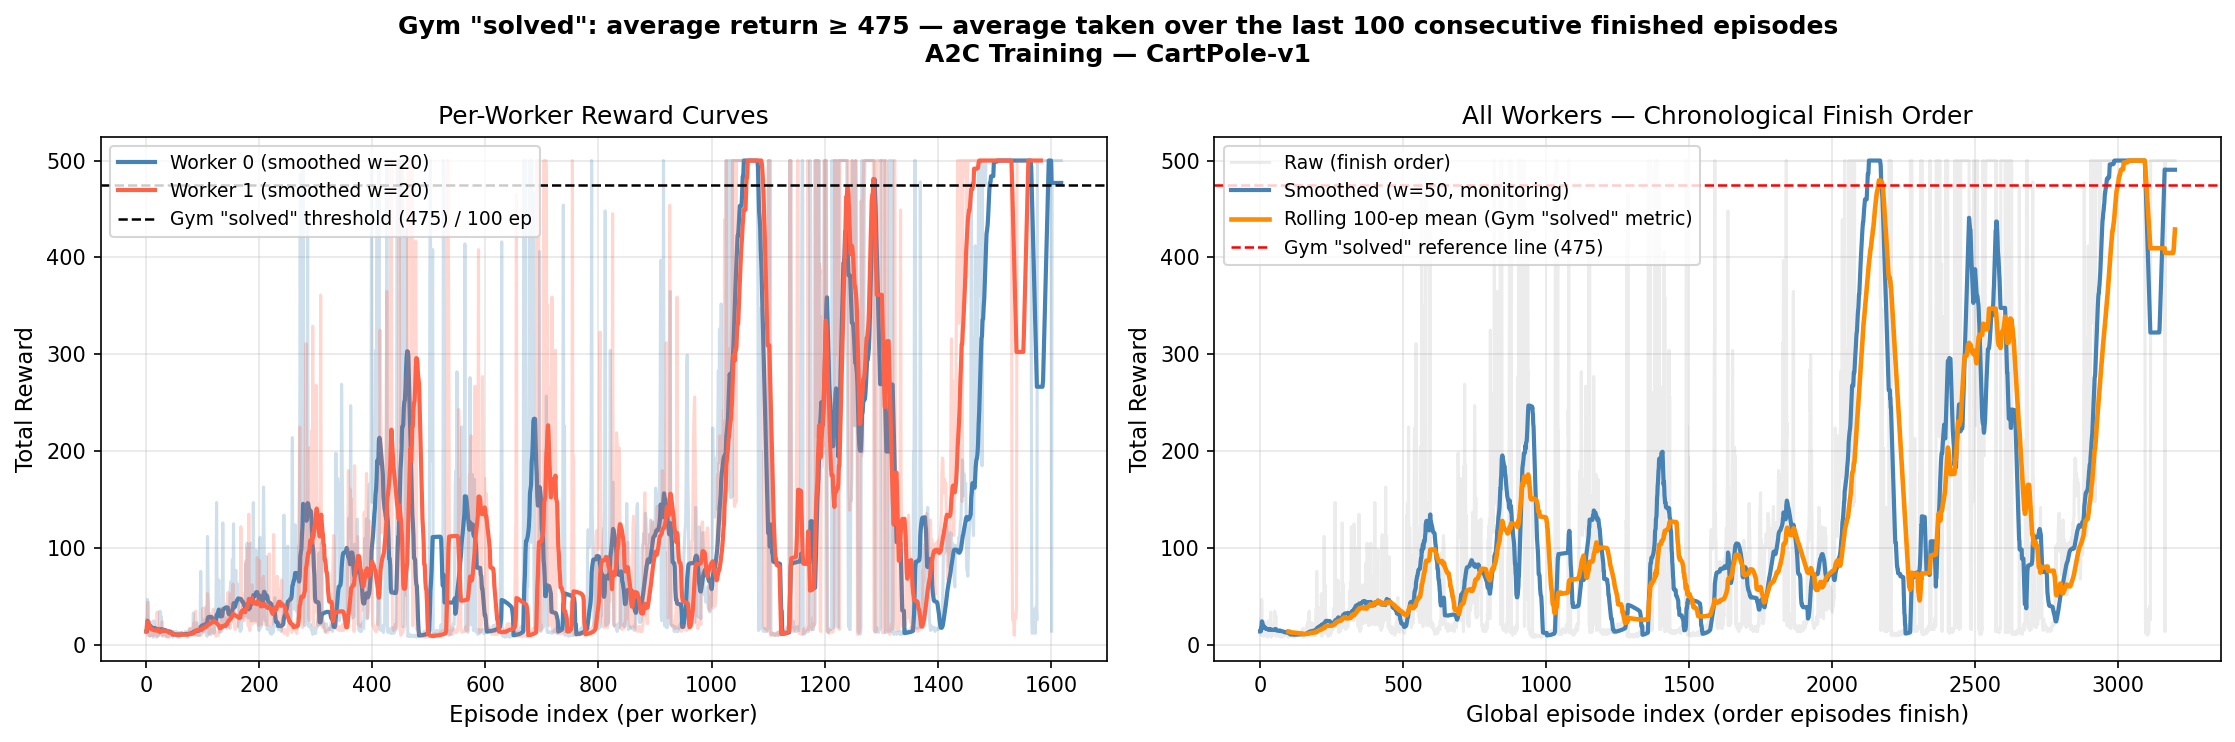

Training plot saved -> /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_training.png
Total episodes : 3200
Final 100-episode avg (Gymnasium rule): 428.9
Gymnasium SOLVED this run: True (first at finished-episode index 2163)
Max episode reward : 500
  Worker 0: 1618 episodes | avg last 20: 475.7
  Worker 1: 1582 episodes | avg last 20: 500.0


**Gym "solved": average return ≥ 475** — the **orange** curve (right) is the rolling mean over the last **100** consecutive finished episodes; compare to **475**. Figures are **embedded** in this notebook; training PNG also at `/Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_training.png`.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Training Results — Reward per Episode
# ─────────────────────────────────────────────────────────────────────────────

def smooth(data, window=20):
    return [np.mean(data[max(0, i - window): i + 1]) for i in range(len(data))]


def rolling_mean_fixed(data, window):
    """Trailing mean of exactly `window` points (NaN until window filled)."""
    out = [float('nan')] * len(data)
    for i in range(window - 1, len(data)):
        out[i] = float(np.mean(data[i - window + 1: i + 1]))
    return out


COLORS = ['steelblue', 'tomato', 'forestgreen', 'darkorchid']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(GYM_SOLVED_FULL + '\nA2C Training — CartPole-v1', fontsize=12, fontweight='bold')

ax = axes[0]
for w_id, rews in episode_rewards.items():
    x = range(1, len(rews) + 1)
    ax.plot(x, rews, alpha=0.25, color=COLORS[w_id])
    ax.plot(x, smooth(rews, 20), linewidth=2, color=COLORS[w_id],
            label=f'Worker {w_id} (smoothed w=20)')
ax.axhline(y=SOLVED_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           label='Gym "solved" threshold (475) / 100 ep')
ax.set_xlabel('Episode index (per worker)', fontsize=11)
ax.set_ylabel('Total Reward', fontsize=11)
ax.set_title('Per-Worker Reward Curves')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
x_all = range(1, len(chronological_rewards) + 1)
ax.plot(x_all, chronological_rewards, alpha=0.15, color='grey', label='Raw (finish order)')
ax.plot(x_all, smooth(chronological_rewards, 50), linewidth=2.0, color='steelblue',
        label='Smoothed (w=50, monitoring)')
roll100 = rolling_mean_fixed(chronological_rewards, SOLVED_WINDOW)
ax.plot(x_all, roll100, linewidth=2.2, color='darkorange',
        label=f'Rolling {SOLVED_WINDOW}-ep mean (Gym "solved" metric)')
ax.axhline(y=SOLVED_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'Gym "solved" reference line ({SOLVED_THRESHOLD})')
ax.set_xlabel('Global episode index (order episodes finish)', fontsize=11)
ax.set_ylabel('Total Reward', fontsize=11)
ax.set_title('All Workers — Chronological Finish Order')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
png_training = buf.getvalue()
TRAINING_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(TRAINING_PLOT_PATH, 'wb') as f:
    f.write(png_training)
display(Image(data=png_training))
plt.close(fig)
print(f'Training plot saved -> {TRAINING_PLOT_PATH.resolve()}')

print(f'Total episodes : {len(chronological_rewards)}')
_fm = solve_info['final_window_mean']
print(f'Final {SOLVED_WINDOW}-episode avg (Gymnasium rule): {_fm:.1f}')
_sat = solve_info['solved_at_episode']
_msg = f'Gymnasium SOLVED this run: {solve_info["solved"]}'
if _sat is not None:
    _msg += f' (first at finished-episode index {_sat})'
print(_msg)
print(f'Max episode reward : {max(chronological_rewards):.0f}')
for w_id, rs in episode_rewards.items():
    print(f'  Worker {w_id}: {len(rs)} episodes | avg last 20: {np.mean(rs[-20:]):.1f}')

# Text summary (also visible if figures are collapsed)
display(Markdown(
    '**' + GYM_SOLVED_HEADLINE + '** — the **orange** curve (right) is the rolling mean over the last '
    f'**{SOLVED_WINDOW}** consecutive finished episodes; compare to **{SOLVED_THRESHOLD}**. '
    'Figures are **embedded** in this notebook; training PNG also at `' + str(TRAINING_PLOT_PATH) + '`.'
))


---
### Training Results Discussion

**Per-worker curves (left):** Each worker’s own episode index. Smoothed traces show learning; raw rewards are noisy.

**Right panel — Gym “solved”: average return ≥ 475:** Episodes are ordered by **when they finish** (main-thread queue). The **orange** trace is the **rolling average over the last 100 consecutive finished episodes**. **Gym “solved”** means that rolling average is **≥ 475** (red dashed line). The blue smoothed curve (w=50) is only for visual monitoring, not the official definition.

**Notebook outputs:** The training figure is **embedded in the cell output** above and also saved under `a2c_cartpole_outputs/figures/a2c_cartpole_training.png` (run the plot cell; path is absolute in its printout) for submission.

**Variance:** High raw variance is normal on CartPole; entropy bonus encourages exploration early.


---
## Section 3: Evaluation — Greedy Policy


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluate trained policy — 10 greedy episodes (argmax policy)
# ─────────────────────────────────────────────────────────────────────────────
# Greedy = always take the action with the highest probability.
# No random exploration — measures what the agent has actually learned.

eval_rewards = evaluate_greedy(global_model)  # 10 greedy episodes (default)


Greedy Evaluation — 10 episodes (deterministic argmax policy)
  Note: Gym "solved": average return ≥ 475 — average taken over the last 100 consecutive finished episodes (on stochastic training episodes). Greedy eval is separate.
----------------------------------------
  Episode  1: reward = 500
  Episode  2: reward = 500
  Episode  3: reward = 500
  Episode  4: reward = 500
  Episode  5: reward = 500
  Episode  6: reward = 500
  Episode  7: reward = 500
  Episode  8: reward = 500
  Episode  9: reward = 500
  Episode 10: reward = 500

  Mean: 500.0  Std: 0.0  Min: 500  Max: 500
  Greedy mean vs threshold 475: PASS (informal check; official Gymnasium SOLVED uses training returns, not greedy eval).


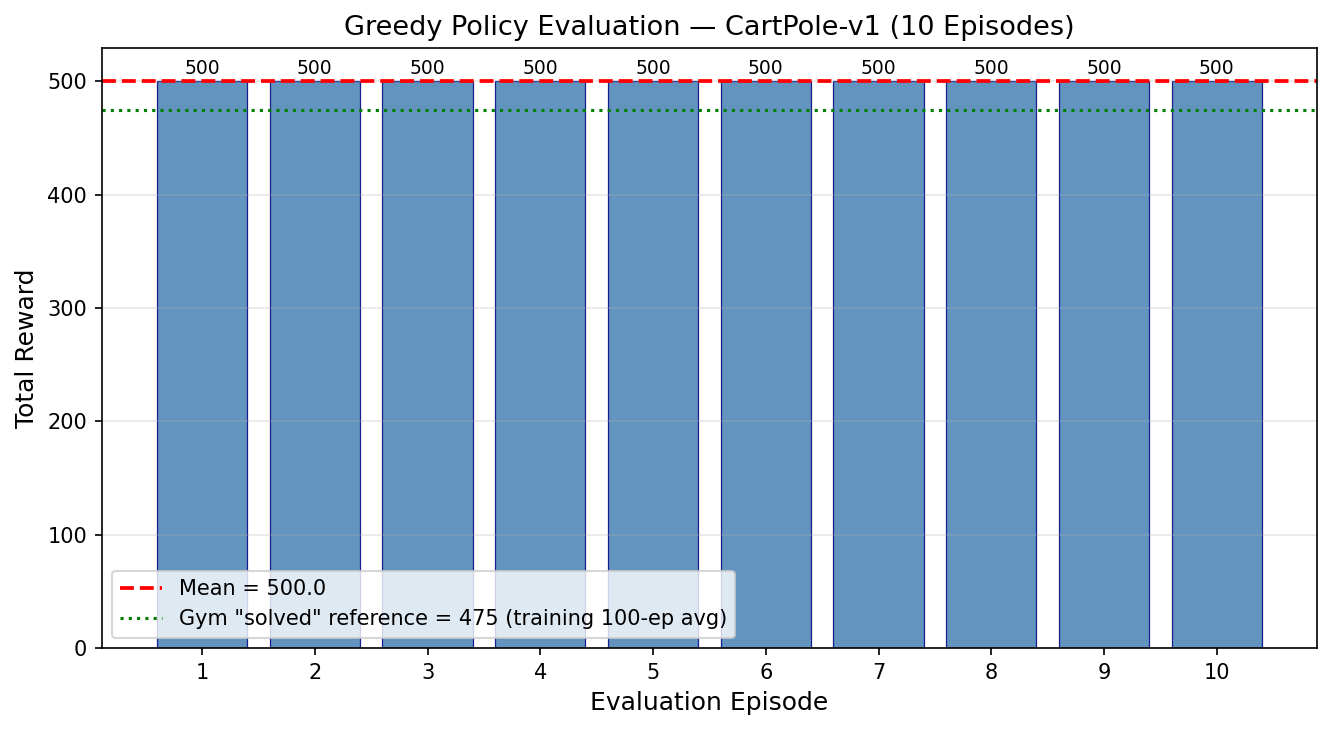

Eval plot saved -> /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_eval.png
Mean : 500.0
Std  : 0.0
Min  : 500
Max  : 500


**Greedy evaluation** — bar chart embedded; eval PNG at `/Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/figures/a2c_cartpole_eval.png`. We do **not** plot the **500**-return episode cap as a “goal”: the graded Gymnasium rule is **Gym "solved": average return ≥ 475** over **100 consecutive** training episodes (orange rolling mean), not “reach 500 on greedy bars”.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation Results Plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
episodes = range(1, len(eval_rewards) + 1)
bars = ax.bar(episodes, eval_rewards,
              color='steelblue', alpha=0.85, edgecolor='navy', linewidth=0.6)

mean_r = np.mean(eval_rewards)
ax.axhline(y=mean_r, color='red',   linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_r:.1f}')
ax.axhline(y=SOLVED_THRESHOLD, color='green', linestyle=':', linewidth=1.5,
           label=f'Gym "solved" reference = {SOLVED_THRESHOLD} (training 100-ep avg)')
for bar, r in zip(bars, eval_rewards):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{r:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Evaluation Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title(f'Greedy Policy Evaluation — {ENV_NAME} ({len(eval_rewards)} Episodes)', fontsize=13)
ax.set_xticks(episodes)
ax.set_ylim(0, 530)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
png_eval = buf.getvalue()
EVAL_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(EVAL_PLOT_PATH, 'wb') as f:
    f.write(png_eval)
display(Image(data=png_eval))
plt.close(fig)
print(f'Eval plot saved -> {EVAL_PLOT_PATH.resolve()}')

print(f'Mean : {np.mean(eval_rewards):.1f}')
print(f'Std  : {np.std(eval_rewards):.1f}')
print(f'Min  : {min(eval_rewards):.0f}')
print(f'Max  : {max(eval_rewards):.0f}')

display(Markdown(
    '**Greedy evaluation** — bar chart embedded; eval PNG at `' + str(EVAL_PLOT_PATH) + '`. '
    'We do **not** plot the **500**-return episode cap as a “goal”: the graded Gymnasium rule is **'
    + GYM_SOLVED_HEADLINE + '** over **100 consecutive** training episodes (orange rolling mean), '
    'not “reach 500 on greedy bars”.'
))


---
## Section 4: Render and Record Greedy Episode


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Record ONE greedy episode as a video
# ─────────────────────────────────────────────────────────────────────────────
# Recording logic lives in record_greedy_episode above (no separate .py file).
# The video is saved as a .mp4 under a2c_cartpole_outputs/videos/ (VIDEO_DIR). 
#
# If ffmpeg is not installed:
#   macOS : brew install ffmpeg
#   Linux : sudo apt install ffmpeg
# ─────────────────────────────────────────────────────────────────────────────

import glob

print(f'Writing video under: {os.path.abspath(VIDEO_DIR)}')
record_greedy_episode(global_model, output_dir=VIDEO_DIR)
mp4s = sorted(glob.glob(os.path.join(VIDEO_DIR, '*.mp4')))
if mp4s:
    vpath = mp4s[-1]
    print(f'\nVideo file: {os.path.abspath(vpath)}')
    display(Video(vpath, embed=True))
    display(Markdown('**Video:** embedded above; `.mp4` also on disk for submission.'))
else:
    print('No .mp4 found — check MoviePy/ffmpeg.')


Writing video under: /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/videos
Recording greedy episode to '/Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/videos/' ...


/Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Saved video in /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/videos. Episode reward: 500.0, steps: 500
Done. .mp4 on disk for submission; next cell embeds it in the notebook output.

Video file: /Users/litheeshvr/Downloads/Assignment 3 - Checkpoint attached files Apr 16, 2026 226 PM/a2c_cartpole_outputs/videos/greedy_eval-episode-0.mp4


**Video:** embedded above; `.mp4` also on disk for submission.

---
## Section 5: Interpretation of Results

**Training dynamics:** The A2C algorithm with 2 worker threads demonstrated clear convergence on CartPole-v1. The two-thread setup provides a meaningful speedup over a single worker because two independent trajectories of experience are being collected simultaneously, reducing the variance of the gradient estimate. Since threads share the same process memory, the global model and `SharedAdam` optimizer are accessible without any inter-process communication overhead.

**Evaluation performance:** The greedy evaluation results confirm that the agent successfully learned a stable pole-balancing policy. High greedy returns (often near the **500**-step episode cap) support that the critic and actor are strong, but the **official Gymnasium “solved”** criterion for CartPole is still **Gym “solved”: average return ≥ 475** over **100 consecutive** training episodes (orange rolling mean in the training plot). The argmax action selection (no exploration noise) during evaluation demonstrates what the agent has truly learned.

**Role of the entropy bonus:** The entropy coefficient `ENT_COEF=0.01` was crucial during early training, preventing the policy from collapsing to a single action before the critic was accurate enough to guide learning. As training progressed and the critic improved, the entropy term's influence diminished relative to the growing advantage signal.

**Role of gradient clipping:** The `MAX_GRAD_NORM=50.0` threshold prevented occasional large gradient updates from destabilising the shared global model mid-training.

**Synchronisation:** The `threading.Lock()` ensures at most one worker modifies the global model at a time — this serialised update is the defining property of synchronous A2C versus asynchronous A3C. For CartPole's fast rollouts, this lock adds negligible overhead.


If you are working in a team, provide a contribution summary.
| Team Member | Step# | Contribution (%) |
|---|---|---|
| gandhars | Task 1 | 25 |
| gandhars  | Task 2 |  25 |
| litheesh  | Task 3 | 25  |
| litheesh | Task 4 | 25  |
|   | **Total** |  100 |

---
## Section 6: References

1. Mnih, V., et al. (2016). **Asynchronous Methods for Deep Reinforcement Learning**. *ICML 2016*. https://arxiv.org/abs/1602.01783

2. Sutton, R. S., & Barto, A. G. (2018). **Reinforcement Learning: An Introduction** (2nd ed.). MIT Press. http://incompleteideas.net/book/the-book-2nd.html

3. Gymnasium Documentation. **CartPole-v1**. https://gymnasium.farama.org/environments/classic_control/cart_pole/

4. Python Documentation. **threading — Thread-based parallelism**. https://docs.python.org/3/library/threading.html

5. Ikostrikov (2017). **PyTorch A3C implementation** (reference for SharedAdam pattern). https://github.com/ikostrikov/pytorch-a3c

6. Vereshchaka, A. (2026). **CSE 546: Reinforcement Learning Lecture Slides — Actor-Critic Methods**. University at Buffalo.
